 # **Project Name**    - NYC Airbnb Exploratory Data Analysis

##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Submitted By - Daksh Yadav**


# **Project Summary -:**

This project performs Exploratory Data Analysis (EDA) on the New York City Airbnb 2019 dataset, which contains 48,895 Airbnb listings and 16 features. The objective of this project is to understand the dataset, clean the data, and discover useful patterns using Python libraries such as Pandas, Matplotlib, and Seaborn.

The analysis begins by exploring the structure of the dataset, checking data types, identifying missing values, and looking for duplicate records. During the data cleaning process, it was observed that the last_review and reviews_per_month columns contain several missing values, while the name and host_name columns have only a few missing entries. Basic statistical analysis was performed to understand the distribution of numerical features such as price, minimum nights, number of reviews, and availability.

The dataset includes listings from all five New York City boroughs: Manhattan, Brooklyn, Queens, Bronx, and Staten Island. The analysis shows that Manhattan (21,661 listings) and Brooklyn (20,104 listings) have the highest number of Airbnb properties, making them the most popular locations on the platform. Most listings are either Entire homes/apartments (25,409) or Private rooms (22,326), while Shared rooms (1,160) make up only a small portion of the dataset.

The average listing price is around 153 dollar, while the median price is 106 dollar, indicating that a few very expensive listings (up to 10,000) increase the average price. This suggests the presence of outliers in the dataset. Through charts and visualizations, the project compares prices, room types, availability, and review patterns across different boroughs.

Overall, this project demonstrates the fundamental steps of Exploratory Data Analysis, including data cleaning, statistical summary, and visualization. It provides a better understanding of the Airbnb market in New York City and helps beginners learn how to extract meaningful insights from real-world data before moving on to predictive analytics or machine learning projects.



# **GitHub Link -**

Github Link - https://github.com/Daksh374/EDA_Project

# **Problem Statement**


New York City is one of the most competitive and dynamic tourism destinations globally, making the short-term rental market highly complex. For Airbnb and its hosts, optimizing listings for maximum occupancy and revenue is a major challenge. 
Key questions include:-
 1. How do pricing and availability fluctuate across different NYC boroughs? 
 2. What room types are most preferred by guests, and how do they affect the listing price? 
 3. Are there specific geographic hotspots where listings are concentrated, and how does host behavior (like managing multiple properties) affect listing performance? 
 4. Without answering these questions, hosts struggle with sub-optimal pricing and low occupancy, while Airbnb loses potential platform revenue. 
 This project analyzes the 2019 NYC listing data to solve these challenges through data-driven recommendations.


#### **Define Your Business Objective?**

The primary business objective is to analyze host behavior, regional pricing trends, and customer demand patterns in New York City to provide actionable insights for:
1. **Host Revenue Optimization**: Helping hosts set competitive prices based on location and room type.
2. **Platform Growth**: Identifying underserved boroughs (e.g., Queens, Bronx) with high customer satisfaction (average reviews per month) for listing expansion.
3. **Customer Experience**: Analyzing availability and review trends to recommend policies that improve booking conversion rates and occupancy.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv('/Users/dakshyadav/Desktop/GENAI-WINNOVATION/Projects/EDA_Project /AB_NYC_2019.csv')

### Dataset First View

In [3]:
# Dataset First Look
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
print(f'Number of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')

Number of rows: 48895
Number of columns: 16


### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
duplicate_count = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicate_count}')


Number of duplicate rows: 0


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
missing_values = df.isnull().sum()
print('Missing values in each column:')
print(missing_values[missing_values > 0])

Missing values in each column:
name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64


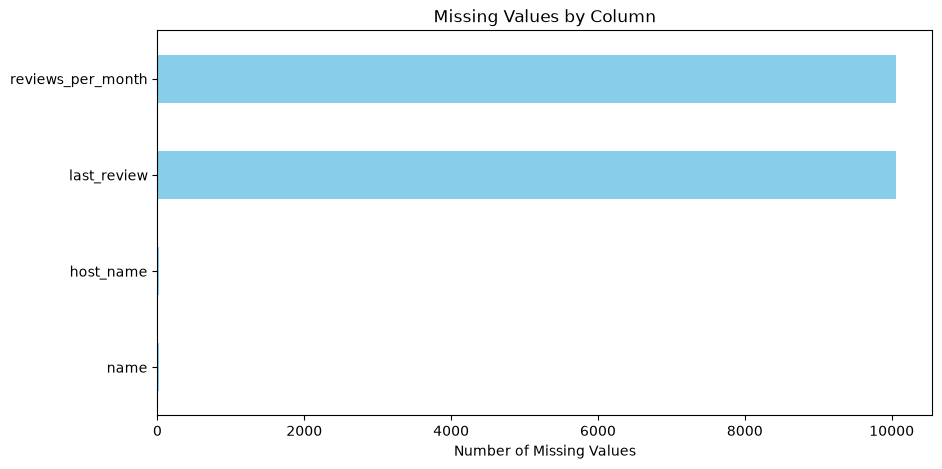

In [8]:
# Visualizing the missing values
missing = df.isnull().sum()

missing = missing[missing > 0]  # Only columns with missing values

plt.figure(figsize=(10,5))
missing.sort_values().plot(kind='barh', color='skyblue')
plt.xlabel("Number of Missing Values")
plt.title("Missing Values by Column")
plt.show()

### What did you know about your dataset?

Based on our initial inspection of the dataset:
1. **Size**: The dataset contains 48,895 rows and 16 columns.
2. **Missing Values**:
   - `name`: 16 missing values (can be filled with 'Unknown').
   - `host_name`: 21 missing values (can be filled with 'Unknown').
   - `last_review` and `reviews_per_month`: 10,052 missing values. These represent listings that have never received a review (`number_of_reviews = 0`). We can fill `reviews_per_month` with 0.0 and `last_review` with 'Not Reviewed'.
3. **Data Types**: The dataset has 3 float columns, 7 integer columns, and 6 object (categorical/string) columns.
4. **Duplicates**: No duplicate rows are present, which is excellent for data integrity.


## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')

In [11]:
# Dataset Describe
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


### Variables Description

Here is the description of all the variables (columns) in the Airbnb dataset:
1. **id**: A unique identifier for each listing.
2. **name**: The title/name of the listing as shown on Airbnb.
3. **host_id**: A unique identifier for the host of the listing.
4. **host_name**: The name of the host.
5. **neighbourhood_group**: The broader borough group in NYC where the listing is located (Manhattan, Brooklyn, Queens, Bronx, Staten Island).
6. **neighbourhood**: The specific neighborhood name (e.g. Astoria, Williamsburg, Harlem).
7. **latitude**: The GPS latitude coordinate of the listing.
8. **longitude**: The GPS longitude coordinate of the listing.
9. **room_type**: The category of accommodation offered (Entire home/apt, Private room, Shared room).
10. **price**: The rental price per night (in USD).
11. **minimum_nights**: The minimum number of nights required to book the listing.
12. **number_of_reviews**: The total number of reviews received by the listing.
13. **last_review**: The date of the most recent review.
14. **reviews_per_month**: The average number of reviews the listing receives each month.
15. **calculated_host_listings_count**: The total number of listings the host has on Airbnb in New York City.
16. **availability_365**: The number of days in a year (out of 365) that the listing is available for booking.


### Check Unique Values for each variable.

In [12]:
# Check Unique Values for each variable.
print('Unique values in neighbourhood group:', df['neighbourhood_group'].unique())
print('Unique values in room type:', df['room_type'].unique())
print('Number of unique specific neighbourhoods:', df['neighbourhood'].nunique())


Unique values in neighbourhood group: <StringArray>
['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx']
Length: 5, dtype: str
Unique values in room type: <StringArray>
['Private room', 'Entire home/apt', 'Shared room']
Length: 3, dtype: str
Number of unique specific neighbourhoods: 221


## 3. ***Data Wrangling***

### Data Wrangling Code

In [15]:
# Write your code to make your dataset analysis ready.
df_clean = df.copy()

# Fill missing values
df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0.0)
df_clean['last_review'] = df_clean['last_review'].fillna('Not Reviewed')
df_clean['name'] = df_clean['name'].fillna('Unknown')
df_clean['host_name'] = df_clean['host_name'].fillna('Unknown')

# Check if there are any remaining null values
print('Null Values in orginal Dataset')
print(df.isnull().sum())

print('\nNull Values after cleaning')
print(df_clean.isnull().sum())

Null Values in orginal Dataset
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Null Values after cleaning
id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0


### What all manipulations have you done and insights you found?

We performed the following data wrangling manipulations:
1. **Handling Missing Values**:
   - Filled nulls in `reviews_per_month` with `0.0`, as a null value indicates that the listing has zero reviews.
   - Filled nulls in `last_review` with `'Not Reviewed'` to provide a descriptive string instead of NaN.
   - Filled nulls in the textual fields `name` and `host_name` with `'Unknown'` to ensure data completeness without losing rows.
2. **Creating Cleaned DataFrame**: All manipulations were performed on a copy (`df_clean`) to keep the raw data intact.
3. **Data Verification**: Verified that there are 0 remaining missing values in the dataset.


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

In [ ]:
# Chart - 1 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 2

In [ ]:
# Chart - 2 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 3

In [ ]:
# Chart - 3 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 4

In [ ]:
# Chart - 4 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 5

In [ ]:
# Chart - 5 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 6

In [ ]:
# Chart - 6 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

In [ ]:
# Chart - 7 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

In [ ]:
# Chart - 8 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

In [ ]:
# Chart - 9 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

In [ ]:
# Chart - 10 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

In [ ]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

In [ ]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

In [ ]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [ ]:
# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

In [ ]:
# Pair Plot visualization code

In [ ]:
sns.pairplot(df)

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***